<h1 align='center'> <b> Penguins </b> </h1>

You are a junior data analyst at a wildlife research center. Your team collected measurements
of penguins from different islands. Management wants you to clean the data, explore
patterns, and finally build a simple model to predict the penguin species.
The work is structured as follows:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Part A: Understanding the Dataset

### Q1: Load the penguins dataset from seaborn into a DataFrame named df and display the first 5 rows.

In [4]:
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Q2: dataset shape, column names, data types:

In [11]:
print(df.shape, df.columns, df.dtypes, sep="\n\n")

(344, 7)

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


### Q3: Check for missing values in each column:

In [16]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

### Q4: df_clean by: 
1. Removing fully duplicated rows
2. Handling missing values:
    For numeric columns: fill missing values with the median
    For categorical columns: fill missing values with the mode
3. Then verify there are no missing values remaining

In [19]:
# df_clean = df.drop_duplicates().copy()

# num_cols = df_clean.select_dtypes(include='number').columns
# cat_cols = df_clean.select_dtypes(exclude='number').columns

# df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())
# df_clean[cat_cols] = df_clean[cat_cols].apply(lambda s: s.fillna(s.mode().iloc[0]))

# df_clean.isna().sum()

np.int64(0)

In [42]:
df_clean = df.drop_duplicates().copy()

In [43]:
nums = df_clean.select_dtypes('float64').columns
categorical = df_clean.select_dtypes('object').columns
df_clean[nums]=df_clean[nums].fillna(df_clean[nums].median())
df_clean[categorical] = df_clean[categorical].fillna(df_clean[categorical].mode().iloc[0])

In [44]:
df_clean.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

# Part B: Filtering, Sorting, and Aggregation

### Q5: Filter the dataset to include only penguins from the island "Biscoe"

In [49]:
biscoe_df = df[df['island'] == 'Biscoe']
biscoe_df.shape

(168, 7)

### Q6: Find all pinguins with:
<ul> 
<li> body_mass_g > overall mean body mass </li>
<li> sex = Male </li>
</ul>

In [58]:
df.columns
mask1 = df_clean['body_mass_g'] > df_clean['body_mass_g'].mean()
mask2 = df_clean['sex'] == 'Male'
heavy_males = df_clean[mask1 & mask2]
heavy_males.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,Male
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male
17,Adelie,Torgersen,42.5,20.7,197.0,4500.0,Male
39,Adelie,Dream,39.8,19.1,184.0,4650.0,Male


### Q7: Sort df_clean by:
1. body_mass_g (descending)
2. then bill_length_mm (ascending)

In [61]:
df_clean.sort_values(by=['body_mass_g', 'bill_length_mm'], ascending=[False,True])
df_clean.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,Male
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.30,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.90,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.20,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.10,18.1,193.0,3475.0,Male
9,Adelie,Torgersen,42.00,20.2,190.0,4250.0,Male


### Q8: Compute the following aggregations:
1. Mean body_mass_g per species . Sort values in descending order.
2. Mean bill_length_mm per ( species , sex )
3. Count of records per island

In [102]:
print(df_clean.groupby('species')['body_mass_g'].mean().sort_values(ascending=False), '\n')

species
Gentoo       5067.741935
Chinstrap    3733.088235
Adelie       3702.960526
Name: body_mass_g, dtype: float64 



In [104]:
print("bill_length_mm mean for species and sex\n", df_clean.groupby(['species', 'sex'])['bill_length_mm'].mean())

bill_length_mm mean for species and sex
 species    sex   
Adelie     Female    37.257534
           Male      40.280380
Chinstrap  Female    46.573529
           Male      51.094118
Gentoo     Female    45.563793
           Male      49.164394
Name: bill_length_mm, dtype: float64


In [105]:
print(df_clean['island'].value_counts())


island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


### Q9: Feature engineering:
Create a new column bill_ratio = bill_length_mm / bill_depth_mm .
1. Add it to df_clean
2. Show summary statistics for bill_ratio
3. Identify which species has the highest average bill_ratio

In [110]:
df_clean['bill_ration'] = df_clean.bill_length_mm / df_clean.bill_depth_mm
df_clean.bill_ration

0      2.090909
1      2.270115
2      2.238889
3      2.569364
4      1.901554
         ...   
339    2.569364
340    3.272727
341    3.210191
342    3.054054
343    3.099379
Name: bill_ration, Length: 344, dtype: float64

In [111]:
df_clean.bill_ration.describe()

count    344.000000
mean       2.605438
std        0.495930
min        1.639810
25%        2.161882
50%        2.571484
75%        3.097572
max        3.612676
Name: bill_ration, dtype: float64

In [134]:
df_clean.groupby('species')['bill_ration'].mean().sort_values(ascending=False).head(1)

species
Gentoo    3.170703
Name: bill_ration, dtype: float64

# Part C: Visualization and Interpretation


### Q10: Create the following plots using df_clean :
1. Bar plot: count of penguins per species
2. Scatter plot: bill_length_mm vs bill_depth_mm (color by species)

<Axes: xlabel='species', ylabel='count'>

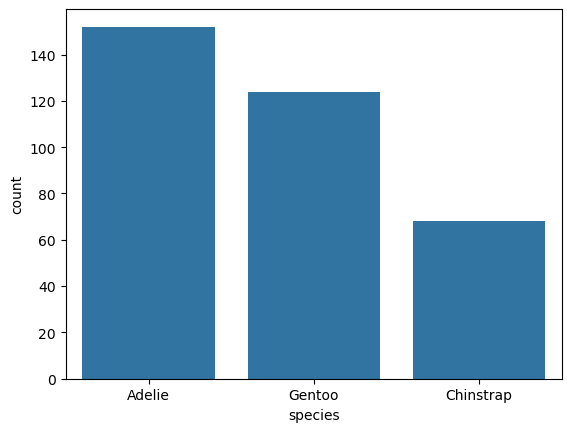

In [137]:
df2 = df_clean['species'].value_counts()
sns.barplot(df2)

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

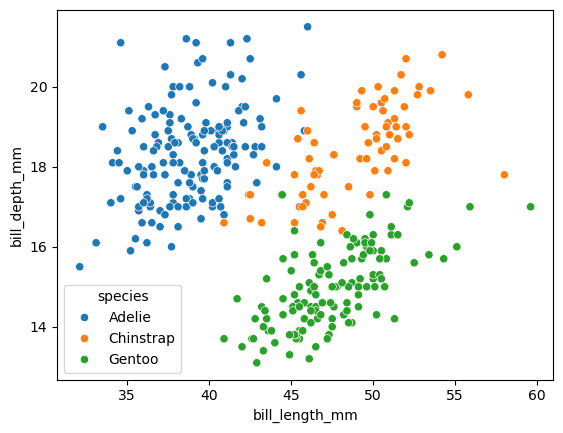

In [148]:
sns.scatterplot(data=df_clean, x='bill_length_mm',y="bill_depth_mm", hue='species')

### Q11: Create a box plot of body_mass_g by species.

<Axes: xlabel='body_mass_g', ylabel='species'>

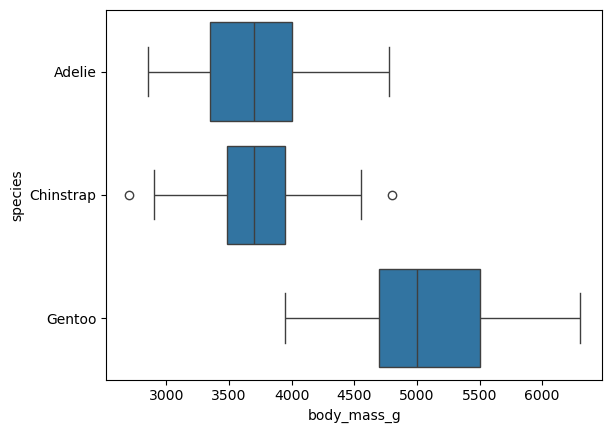

In [151]:
sns.boxplot(df_clean, x='body_mass_g', y="species")

In [152]:
df_clean.groupby('species')['body_mass_g'].describe()

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,152.0,3702.960526,457.922662,2850.0,3350.0,3700.0,4000.0,4775.0
Chinstrap,68.0,3733.088235,384.335081,2700.0,3487.5,3700.0,3950.0,4800.0
Gentoo,124.0,5067.741935,510.447498,3950.0,4700.0,5000.0,5500.0,6300.0


Interpretation:

Adelie:

<li>the range is [2850 - 4775].</li>
<li>50% of pinguins body_mass is [3350-4000] and median is 3700</li>

Chinstrap:

<li> the range is [2700 - 4800]. </li>
<li> There is outliers(2700, 4800) </li> 
<li> 50% of pinguins body_mass is [3500-3950] and median is 3700 </li>

Gentoo:

the range is [3950 - 6300]. There is no outliers. 50% of pinguins body_mass is [4700-5500] and median is 5000
In conclusion Gentoo has the highest weight range and median


### Q12: Compute a correlation matrix for numeric features and visualize it as a heatmap.

<Axes: >

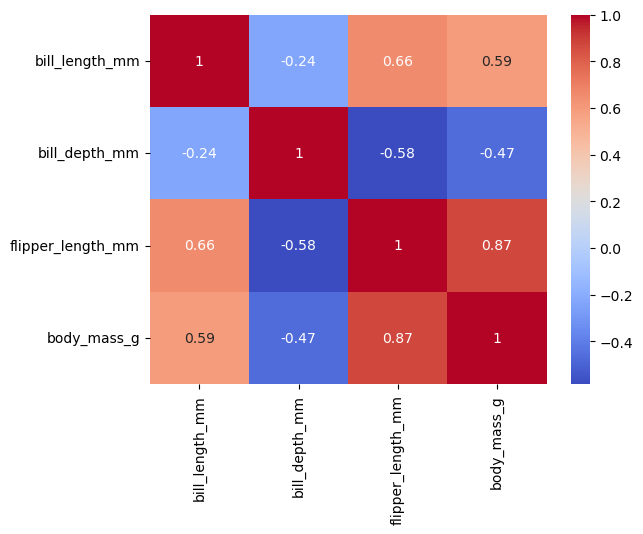

In [160]:
sns.heatmap(df_clean[nums].corr(), annot=True, cmap='coolwarm')

# Part D: Machine Learning


### Q13: Define:
- target y = species
- features X = all other columns EXCEPT species

Then split into train/test using:
- test_size = 0.2
- random_state = 42
- stratify by y

In [162]:
y = df_clean["species"]
X = df_clean.drop(columns=["species"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Q14: Preprocessing Data for ML Training

In [ ]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

### Train models:

#### 1. KNN Classifier with n_neighbors=

In [164]:
knn_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [166]:
knn_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [168]:
knn_model.predict(X_test)

array(['Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap', 'Adelie',
       'Chinstrap', 'Gentoo', 'Chinstrap', 'Chinstrap', 'Adelie',
       'Gentoo', 'Chinstrap', 'Gentoo', 'Gentoo', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap', 'Gentoo', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo',
       'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Gentoo', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo', 'Chinstrap',
       'Chinstrap', 'Adelie', 'Chinstrap', 'Adelie', 'Chinstrap',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap', 'Gentoo',
       'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo'],
      dtype=object)

In [181]:
knn_model.score(X_test, y_test)

0.9855072463768116

#### 2. Logistic Regression (multiclass) with max_iter=2000

In [174]:
logreg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

In [175]:
logreg_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
logreg_model.predict(X_test)

array(['Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap', 'Adelie',
       'Chinstrap', 'Gentoo', 'Chinstrap', 'Chinstrap', 'Adelie',
       'Gentoo', 'Chinstrap', 'Gentoo', 'Gentoo', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap', 'Gentoo', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo',
       'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Gentoo', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo', 'Chinstrap',
       'Adelie', 'Adelie', 'Chinstrap', 'Adelie', 'Chinstrap', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap',
       'Adelie', 'Gentoo', 'Chinstrap', 'Adelie', 'Chinstrap', 'Adelie',
       'Gentoo', 'Gentoo', 'Chinstrap', 'Gentoo', 'Gentoo', 'Chinstrap',
       'Gentoo', 'Adelie', 'Adelie', 'Gentoo'], dtype=object)

In [180]:
logreg_model.score(X_test, y_test)

1.0

### Q16: Conclude based on the accuracy results

Logistic regression ahiceved 100% accuracy whilte KNN model 98,5% that is also good. This can say that relationship in penguin species and featers is linear. 